In [1]:
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt

from src.saws_functions import sarg_grid_from_sat  # noqa: E402

Skipped existing C20241772024183.1KM.GOG.7DAY.L3D.FA_UNET_DENSITY.png
Skipped existing C20241772024183.1KM.GOG.7DAY.L3D.FA_UNET_DENSITY.pgw
Skipped existing C20241772024183.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png
Skipped existing C20241772024183.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.pgw
Skipped existing C20241772024183.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png
Skipped existing C20241772024183.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.pgw
Skipped existing C20241772024183.1KM.ECARIB.7DAY.L3D.FA_UNET_DENSITY.png
Skipped existing C20241772024183.1KM.ECARIB.7DAY.L3D.FA_UNET_DENSITY.pgw
Skipped existing C20241772024183.1KM.PANAMA.7DAY.L3D.FA_UNET_DENSITY.png
Skipped existing C20241772024183.1KM.PANAMA.7DAY.L3D.FA_UNET_DENSITY.pgw
Skipped existing C20241772024183.1KM.JAMAICA.7DAY.L3D.FA_UNET_DENSITY.png
Skipped existing C20241772024183.1KM.JAMAICA.7DAY.L3D.FA_UNET_DENSITY.pgw
Skipped existing C20241772024183.1KM.YUCATAN.7DAY.L3D.FA_UNET_DENSITY.png
Skipped existing C20241772024183.1KM

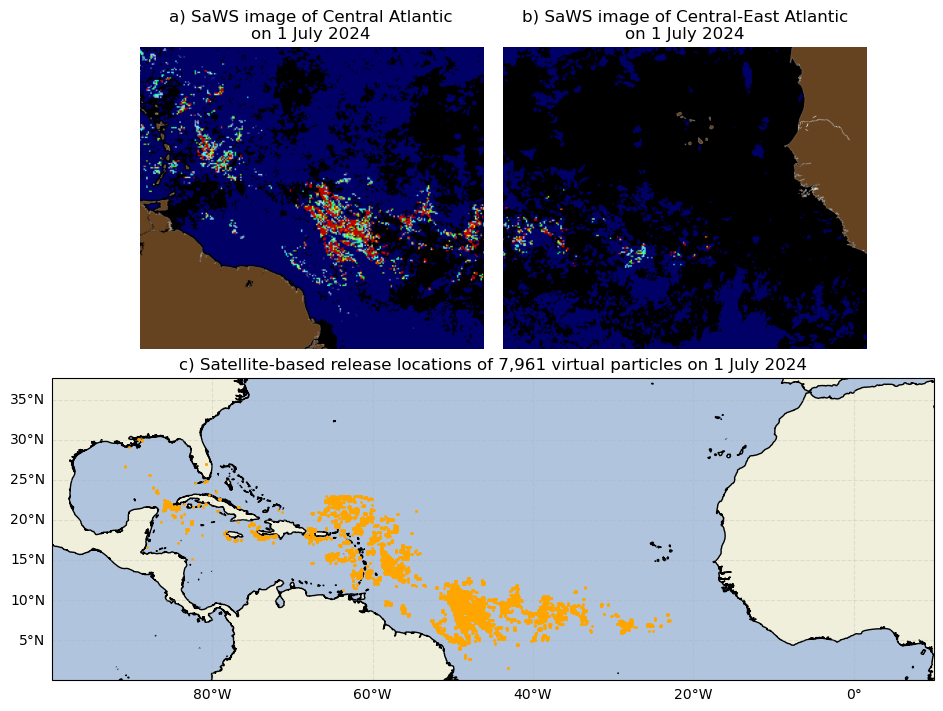

In [5]:
#Loading satellite images
coords = sarg_grid_from_sat(datetime(2024,7,1), stride=8)

images = ['SaWS_downloads/C20241772024183.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png', 'SaWS_downloads/C20241772024183.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png']
#Creating figure layout: top row = 2 PNG images, bottom row = map
fig = plt.figure(figsize=(10, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

#Top-left: Central Atlantic PNG
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(plt.imread(images[0]))
ax1.axis('off')
ax1.set_anchor('E')
ax1.set_title('a) SaWS image of Central Atlantic\non 1 July 2024')

#Top-right: Central-East Atlantic PNG
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(plt.imread(images[1]))
ax2.axis('off')
ax2.set_anchor('W')
ax2.set_title('b) SaWS image of Central-East Atlantic\non 1 July 2024')

#Bottom row: map spanning both columns
ax3 = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
ax3.set_facecolor('lightsteelblue')
ax3.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=2)
ax3.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=1)
ax3.gridlines(draw_labels=['left', 'bottom'], zorder=0, alpha=0.3, linestyle='--')
ax3.scatter(coords[:, 0], coords[:, 1], s=1, color='orange', zorder=5)
ax3.set_extent([-100, 10, 0, 24])
ax3.set_title(f'c) Satellite-based release locations of {len(coords):,} virtual particles on 1 July 2024')

fig.savefig('Figures/Figure1.png', bbox_inches='tight', dpi=300)

plt.show()